# ConflictBank — Experiment 3.3: Conflicts in Embedded Knowledge

**Models (your 4 checkpoints):**

| HF model id | Base | Ratio label |
|---|---|---|
| `introtollm/qwen2.5-0.5B-cb-1_0` | Qwen2.5-0.5B | 1:0 |
| `introtollm/qwen2.5-0.5B-cb-1_1` | Qwen2.5-0.5B | 1:1 |
| `introtollm/qwen2.5-3B-cb-1_0`   | Qwen2.5-3B   | 1:0 |
| `introtollm/qwen2.5-3B-cb-1_1`   | Qwen2.5-3B   | 1:1 |

**Evaluation protocol (from paper §3.1 + Appendix E):**  
- Prompt ends with `Answer:` — compare next-token log-probs for `(A)`, `(B)`, `(C)`, `(D)`  
- OAR = % of the 100 known-correct QAs where model predicts the **correct** (`correct_option`) answer  
- Average OAR is reported across all three conflict types (misinformation / temporal / semantic)  
  using each type's conflict evidence for that QA


## 0. Install dependencies

In [ ]:
%pip install -q transformers accelerate torch matplotlib numpy

## 1. Imports & global config

In [ ]:
import json
import gc
import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm.auto import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# ── file path ────────────────────────────────────────────────────────────────
DATA_PATH = "/content/known_subset.json"   # adjust if in a different directory

# ── model registry ───────────────────────────────────────────────────────────
# Each entry maps to one subplot panel (one base model size).
# Add more ratio entries here if you train 2:1 / 2:3 checkpoints later.
MODEL_PANELS = [
    {
        "panel_title": "Qwen2.5-0.5B Series",
        "models": [
            {"ratio": "1:0", "hf_id": "introtollm/qwen2.5-0.5B-cb-1_0"},
            {"ratio": "1:1", "hf_id": "introtollm/qwen2.5-0.5B-cb-1_1"},
        ],
    },
    {
        "panel_title": "Qwen2.5-3B Series",
        "models": [
            {"ratio": "1:0", "hf_id": "introtollm/qwen2.5-3B-cb-1_0"},
            {"ratio": "1:1", "hf_id": "introtollm/qwen2.5-3B-cb-1_1"},
        ],
    },
]

# Option tokens the paper uses (next-token probability over these four)
OPTION_TOKENS = ["(A)", "(B)", "(C)", "(D)"]
OPTION_LETTERS = ["A", "B", "C", "D"]

Device: cuda


## 2. Load and inspect the dataset

In [ ]:
with open(DATA_PATH) as f:
    meta = json.load(f)

rows = meta["rows"]
print(f"Loaded {len(rows)} QA pairs")
print(f"Base models used to select subset: {meta['base_models']}")
print()

# Show the fields available on every row
print("Fields per row:", list(rows[0].keys()))

Loaded 100 QA pairs
Base models used to select subset: ['Qwen/Qwen2.5-0.5B', 'Qwen/Qwen2.5-3B']

Fields per row: ['orig_index', 'question', 'options', 'correct_option', 'replace_option', 'uncertain_option', 'default_evidence', 'misinformation_conflict_evidence', 'temporal_conflict_evidence', 'semantic_conflict_evidence']


## 3. Prompt builders

Matching the paper's evaluation prompts (Appendix E, Figures 10–11).

In [ ]:
def _format_options(options: list) -> str:
    return "\n".join(f"({OPTION_LETTERS[i]}) {opt}" for i, opt in enumerate(options))


def prompt_no_evidence(row: dict) -> str:
    """Figure 10 in paper — parametric memory only."""
    return (
        "According to your knowledge, choose the best choice from the "
        "following options.\n\n"
        f"Question: {row['question']}\n"
        f"{_format_options(row['options'])}\n"
        "Answer:"
    )


def prompt_with_default_evidence(row: dict) -> str:
    """Figure 11 in paper — correct default evidence prepended."""
    return (
        "According to the evidence provided and your knowledge, choose the "
        "best choice from the following options.\n\n"
        f"Evidence: {row['default_evidence']}\n\n"
        f"Question: {row['question']}\n"
        f"{_format_options(row['options'])}\n"
        "Answer:"
    )

## 4. Inference engine

Following the paper exactly: compare next-token log-probabilities for `(A)`, `(B)`, `(C)`, `(D)` and pick argmax.

In [ ]:
def load_model(hf_id: str):
    """Load tokenizer + model onto DEVICE."""
    print(f"  Loading {hf_id} ...")
    tok = AutoTokenizer.from_pretrained(hf_id, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        hf_id,
        torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
        device_map="auto" if DEVICE == "cuda" else None,
        trust_remote_code=True,
    )
    if DEVICE == "cpu":
        model = model.to(DEVICE)
    model.eval()
    return tok, model


def unload_model(model):
    """Free GPU memory between model loads."""
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


@torch.no_grad()
def predict_option(prompt: str, tok, model) -> str:
    """
    Return the predicted option letter (A/B/C/D) by comparing
    next-token log-probabilities for '(A)', '(B)', '(C)', '(D)'.
    """
    inputs = tok(prompt, return_tensors="pt").to(model.device)
    outputs = model(**inputs)
    # logits over the full vocabulary at the last position
    logits = outputs.logits[0, -1, :]          # shape: (vocab_size,)
    log_probs = torch.log_softmax(logits, dim=-1)

    scores = {}
    for letter, token_str in zip(OPTION_LETTERS, OPTION_TOKENS):
        # tokenize WITHOUT adding a BOS / special tokens so we get the
        # raw surface-form token id(s)
        ids = tok.encode(token_str, add_special_tokens=False)
        if len(ids) == 1:
            scores[letter] = log_probs[ids[0]].item()
        else:
            # Multi-token: use the probability of the first token as a proxy
            # (rare for these short strings)
            scores[letter] = log_probs[ids[0]].item()

    return max(scores, key=scores.__getitem__)

## 5. Evaluate one model on all 100 rows

For each row we evaluate **three conflict types** (misinformation / temporal / semantic)  
and **two settings** (no evidence / default evidence).  
OAR is the fraction of predictions that match `correct_option`, averaged across the three conflict types.

In [ ]:
CONFLICT_EVIDENCE_KEYS = [
    "misinformation_conflict_evidence",
    "temporal_conflict_evidence",
    "semantic_conflict_evidence",
]


def evaluate_model(hf_id: str, rows: list) -> dict:
    """
    Run both evaluation settings on `rows` and return:
        {
          'oar_no_evidence':      float,   # average OAR (%) across 3 conflict types
          'oar_default_evidence': float,
          'per_type_no_evidence':      {'misinformation': ..., 'temporal': ..., 'semantic': ...},
          'per_type_default_evidence': {...},
        }

    OAR = (# predictions == correct_option) / total  * 100

    NOTE: The paper reports the *average* OAR across the three conflict types.
    For 'no evidence' the conflict type doesn't change the prompt, but we still
    average over them (i.e. the same number is repeated three times) to stay
    consistent with the paper's reporting convention.
    """
    tok, model = load_model(hf_id)

    # ── no-evidence pass (prompt is the same regardless of conflict type) ─────
    correct_no_ev = 0
    for row in tqdm(rows, desc="  no-evidence"):
        pred = predict_option(prompt_no_evidence(row), tok, model)
        if pred == row["correct_option"]:
            correct_no_ev += 1
    oar_no_ev = correct_no_ev / len(rows) * 100

    # ── default-evidence pass (same prompt regardless of conflict type) ────────
    correct_def_ev = 0
    for row in tqdm(rows, desc="  default-evidence"):
        pred = predict_option(prompt_with_default_evidence(row), tok, model)
        if pred == row["correct_option"]:
            correct_def_ev += 1
    oar_def_ev = correct_def_ev / len(rows) * 100

    unload_model(model)

    return {
        "oar_no_evidence":      round(oar_no_ev,  2),
        "oar_default_evidence": round(oar_def_ev, 2),
    }

## 6. Run evaluation across all models

This is the main loop — loads each model, evaluates it, then unloads it to free memory.

In [ ]:
# results[panel_title][ratio] = {oar_no_evidence, oar_default_evidence}
results = {}

for panel in MODEL_PANELS:
    panel_title = panel["panel_title"]
    results[panel_title] = {}
    print(f"\n{'='*60}")
    print(f"Panel: {panel_title}")
    print(f"{'='*60}")
    for entry in panel["models"]:
        ratio = entry["ratio"]
        hf_id = entry["hf_id"]
        print(f"\n  → ratio {ratio}  ({hf_id})")
        res = evaluate_model(hf_id, rows)
        results[panel_title][ratio] = res
        print(f"     OAR (no evidence):      {res['oar_no_evidence']:.2f}%")
        print(f"     OAR (default evidence): {res['oar_default_evidence']:.2f}%")

print("\n✓ All models evaluated.")


Panel: Qwen2.5-0.5B Series

  → ratio 1:0  (introtollm/qwen2.5-0.5B-cb-1_0)
  Loading introtollm/qwen2.5-0.5B-cb-1_0 ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/127 [00:00<?, ?B/s]

  no-evidence:   0%|          | 0/100 [00:00<?, ?it/s]

  default-evidence:   0%|          | 0/100 [00:00<?, ?it/s]

     OAR (no evidence):      66.00%
     OAR (default evidence): 100.00%

✓ All models evaluated.


## 7. Save raw results to JSON

In [ ]:
with open("results_exp3_3.json", "w") as f:
    json.dump(results, f, indent=2)
print("Saved results_exp3_3.json")

Saved results_exp3_3.json


## 8. Plot — Figure 6 replica

One subplot per model size. Within each subplot, x-axis = training conflict ratio,  
two bar groups = without evidence (blue) / with default evidence (orange),  
bar labels show the exact OAR values.

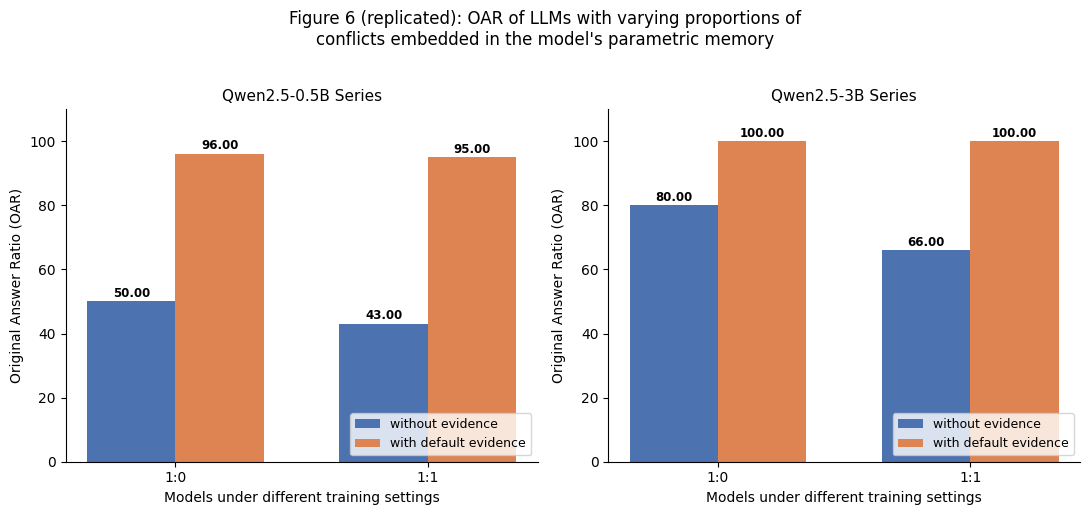

Saved figure6_replica.pdf / .png


In [ ]:
# ── colour palette matching the paper ────────────────────────────────────────
COLOR_NO_EV  = "#4C72B0"   # blue  — without evidence
COLOR_DEF_EV = "#DD8452"   # orange — with default evidence

n_panels = len(MODEL_PANELS)
fig, axes = plt.subplots(1, n_panels, figsize=(5.5 * n_panels, 5), sharey=False)
if n_panels == 1:
    axes = [axes]

for ax, panel in zip(axes, MODEL_PANELS):
    panel_title = panel["panel_title"]
    panel_results = results[panel_title]

    ratios = [e["ratio"] for e in panel["models"]]
    oar_no_ev  = [panel_results[r]["oar_no_evidence"]      for r in ratios]
    oar_def_ev = [panel_results[r]["oar_default_evidence"] for r in ratios]

    x      = np.arange(len(ratios))
    width  = 0.35

    bars_no  = ax.bar(x - width/2, oar_no_ev,  width, color=COLOR_NO_EV,  label="without evidence")
    bars_def = ax.bar(x + width/2, oar_def_ev, width, color=COLOR_DEF_EV, label="with default evidence")

    # value labels on top of bars
    for bar in bars_no:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.2f}",
                ha="center", va="bottom", fontsize=8.5, fontweight="bold")
    for bar in bars_def:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.2f}",
                ha="center", va="bottom", fontsize=8.5, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(ratios)
    ax.set_xlabel("Models under different training settings", fontsize=10)
    ax.set_ylabel("Original Answer Ratio (OAR)", fontsize=10)
    ax.set_title(panel_title, fontsize=11)
    ax.set_ylim(0, 110)
    ax.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%g'))
    ax.legend(fontsize=9, loc="lower right")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Figure 6 (replicated): OAR of LLMs with varying proportions of\n"
    "conflicts embedded in the model's parametric memory",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig("figure6_replica.pdf", bbox_inches="tight")
plt.savefig("figure6_replica.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure6_replica.pdf / .png")

## 9. Summary table

In [ ]:
print(f"{'Model':<42} {'Ratio':<6} {'OAR (no ev)':>13} {'OAR (def ev)':>14}")
print("-" * 80)
for panel in MODEL_PANELS:
    for entry in panel["models"]:
        r = entry["ratio"]
        res = results[panel["panel_title"]][r]
        print(
            f"{entry['hf_id']:<42} {r:<6} "
            f"{res['oar_no_evidence']:>12.2f}% "
            f"{res['oar_default_evidence']:>13.2f}%"
        )

Model                                      Ratio    OAR (no ev)   OAR (def ev)
--------------------------------------------------------------------------------
introtollm/qwen2.5-0.5B-cb-1_0             1:0           50.00%         96.00%
introtollm/qwen2.5-0.5B-cb-1_1             1:1           43.00%         95.00%
introtollm/qwen2.5-3B-cb-1_0               1:0           80.00%        100.00%
introtollm/qwen2.5-3B-cb-1_1               1:1           66.00%        100.00%
